In [ ]:
# Imports
from google.colab import drive
import os
import json
import random
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Mount Google Drive
drive.mount('/content/drive')

/usr/local/lib/python3.13/dist-packages/detectron2/model_zoo/model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Found annotation file at: /content/drive/MyDrive/Assignment 2 CV5570/ACID_3classes/3classes/3classes.json

### Task 1a: Dataset Summary Table

| Metric | Value |
| :--- | :--- |
| Total Image Count | 3929 |
| Annotation Format | COCO JSON |
| Instances: excavator | 2790 |
| Instances: dump_truck | 3701 |
| Instances: dozer | 1123 |
| Train/Val/Test Split | 70/20/10 (2750 Train / 786 Val / 393 Test) |



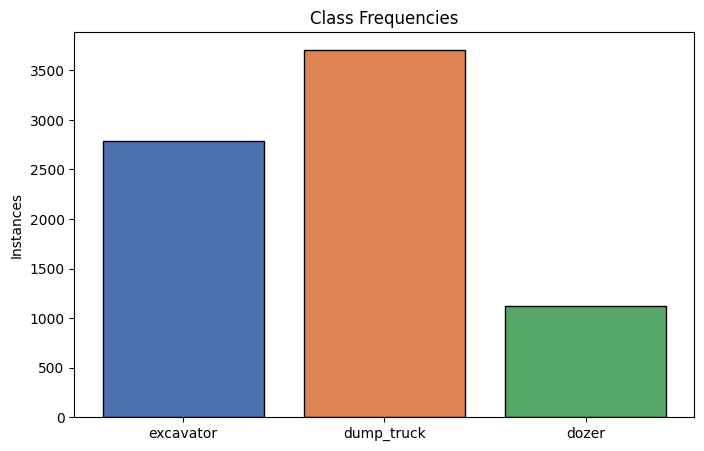

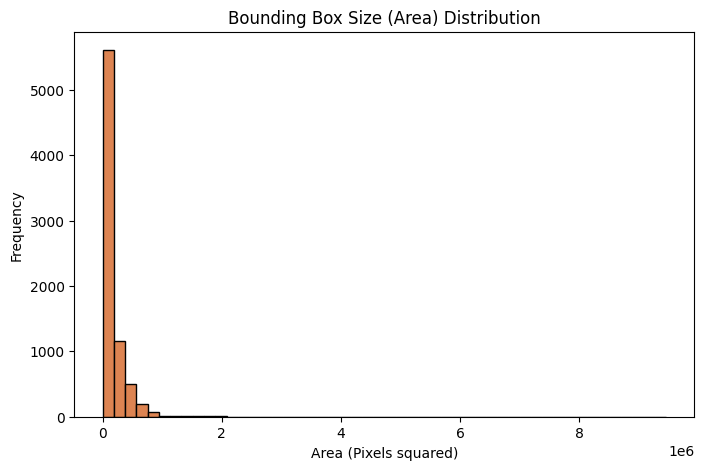

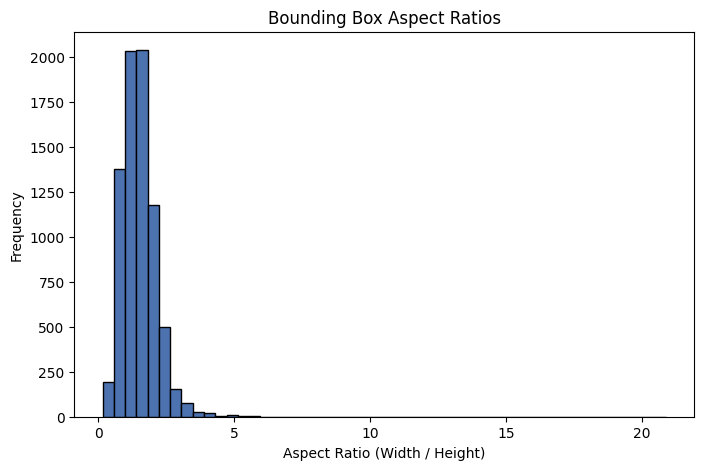

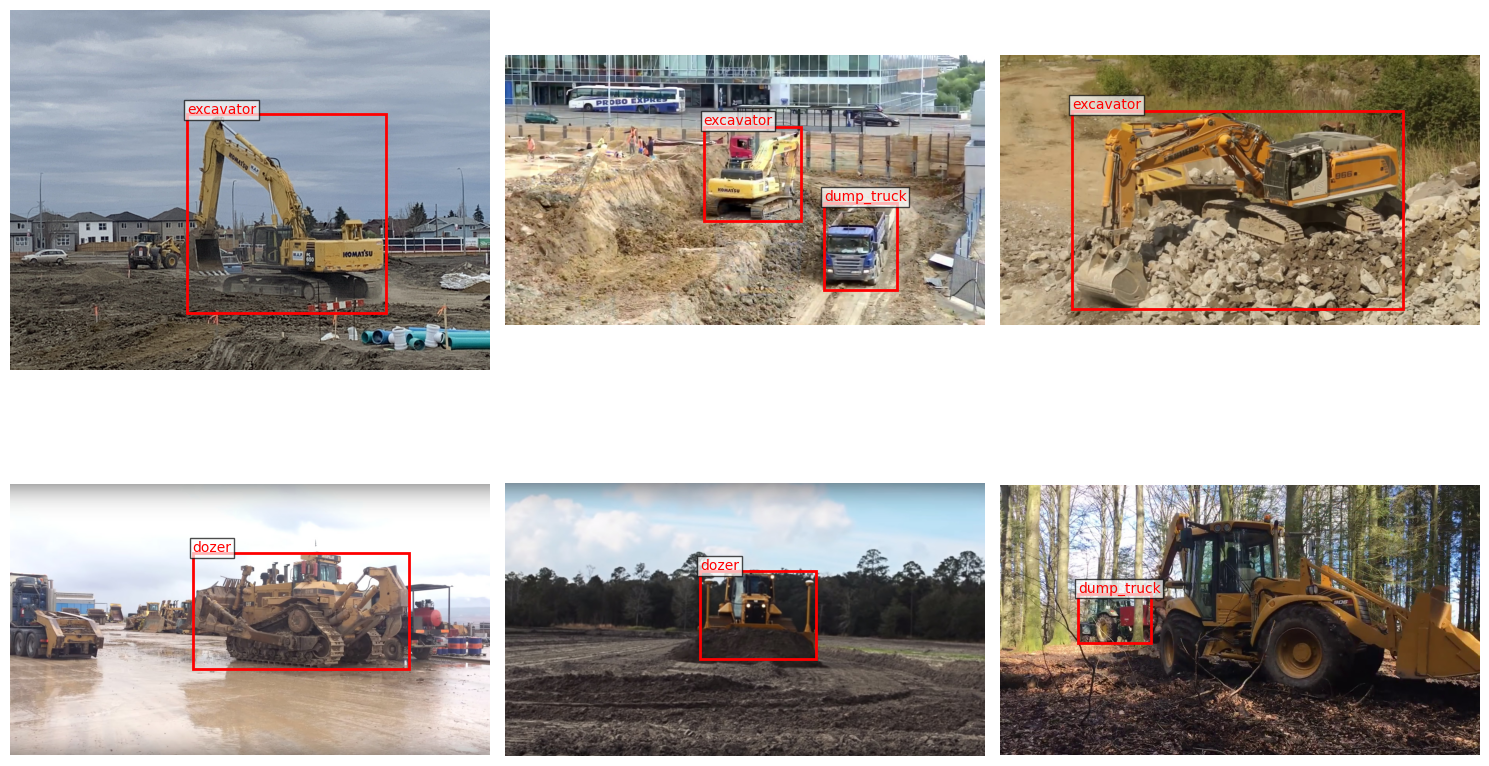

In [11]:
# Directory paths
dataset_dir = '/content/drive/MyDrive/Assignment 2 CV5570/ACID_3classes'
output_dir = '/content/drive/MyDrive/Assignment 2 CV5570/outputs'
os.makedirs(output_dir, exist_ok=True) # Creates the output folder safely without throwing an error if it already exists

# Auto-Locate the JSON file
json_path = None
for root, dirs, files in os.walk(dataset_dir): # os.walk recursively traverses every directory inside your dataset folder
    for file in files:
        if file.endswith('.json'):
            json_path = os.path.join(root, file) # Combines the directory path and filename dynamically
            print(f"Found annotation file at: {json_path}")
            break
    if json_path: break

if not json_path:
    raise FileNotFoundError("Could not find any .json file in the dataset directory.")

# Parse the JSON and Calculate Statistics
with open(json_path, 'r') as f:
    data = json.load(f) # Converts the JSON file text into a nested Python dictionary
    
images = data.get('images', [])
annotations = data.get('annotations', [])
# Dictionary comprehension: Maps the numerical category ID directly to its string name (e.g., {1: 'dozer'})
categories = {cat['id']: cat['name'] for cat in data.get('categories', [])} 

# ---------------- TASK 1A ----------------
total_images = len(images)
# Generator expression inside Counter: Loops through every annotation and tallies the mapped category names
class_counts = Counter(categories.get(ann['category_id']) for ann in annotations)

# Calculate splits (70/20/10) with fixed seed for reproducibility
random.seed(42) # Forces the random number generator to output the exact same shuffle order every time
shuffled_images = images.copy()
random.shuffle(shuffled_images)
train_count = int(total_images * 0.7)
val_count = int(total_images * 0.9) - train_count
test_count = total_images - train_count - val_count

print("\n### Task 1a: Dataset Summary Table\n")
print("| Metric | Value |")
print("| :--- | :--- |")
print(f"| Total Image Count | {total_images} |")
print("| Annotation Format | COCO JSON |")
for name, count in class_counts.items():
    print(f"| Instances: {name} | {count} |")
print(f"| Train/Val/Test Split | 70/20/10 ({train_count} Train / {val_count} Val / {test_count} Test) |\n")

# ---------------- TASK 1B ----------------
bbox_areas = []
aspect_ratios = []

for ann in annotations:
    bbox = ann.get('bbox', []) # COCO format expects a list of 4 floats: [x_top_left, y_top_left, width, height]
    if len(bbox) == 4 and bbox[3] != 0: # bbox[3] is height; preventing division by zero error
        w, h = bbox[2], bbox[3]
        bbox_areas.append(w * h)
        aspect_ratios.append(w / h)

# Class Frequency Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(), color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
plt.title('Class Frequencies')
plt.ylabel('Instances')
plt.savefig(os.path.join(output_dir, '1b_class_frequencies.png'), bbox_inches='tight')
plt.show()

# Bounding Box Size Distribution
plt.figure(figsize=(8, 5))
plt.hist(bbox_areas, bins=50, color='#DD8452', edgecolor='black')
plt.title('Bounding Box Size (Area) Distribution')
plt.xlabel('Area (Pixels squared)')
plt.ylabel('Frequency')
plt.savefig(os.path.join(output_dir, '1b_bbox_sizes.png'), bbox_inches='tight')
plt.show()

# Aspect Ratio Distribution
plt.figure(figsize=(8, 5))
plt.hist(aspect_ratios, bins=50, color='#4C72B0', edgecolor='black')
plt.title('Bounding Box Aspect Ratios')
plt.xlabel('Aspect Ratio (Width / Height)')
plt.ylabel('Frequency')
plt.savefig(os.path.join(output_dir, '1b_aspect_ratios.png'), bbox_inches='tight')
plt.show()

# Six Sample Images with Overlays
img_ann_map = {}
for ann in annotations:
    # setdefault creates an empty list for a new image_id if it doesn't exist, then appends the annotation.
    # This groups all bounding boxes belonging to the same image together for fast lookups.
    img_ann_map.setdefault(ann['image_id'], []).append(ann) 

sample_images = random.sample(images, 6) # Extracts exactly 6 random image dictionaries from the dataset
fig, axes = plt.subplots(2, 3, figsize=(15, 10)) # Initializes a 2-row, 3-column grid of empty plots

for idx, img_info in enumerate(sample_images):
    ax = axes.flatten()[idx] # axes is a 2D array; flatten() makes it 1D so we can access plots sequentially by index
    
    img_name = img_info['file_name']
    img_path = os.path.join(os.path.dirname(json_path), img_name)
    
    # Fallback search if the image isn't right next to the JSON file
    if not os.path.exists(img_path):
        for root, dirs, files in os.walk(dataset_dir):
            if os.path.basename(img_name) in files:
                img_path = os.path.join(root, os.path.basename(img_name))
                break
                
    if os.path.exists(img_path):
        img = plt.imread(img_path) # FIX: Using plt.imread to read the image into a pixel array
        ax.imshow(img) # Renders the pixel array onto the current subplot
        
        # Loop through every bounding box mapped to this specific image
        for ann in img_ann_map.get(img_info['id'], []):
            bbox = ann['bbox']
            cat_name = categories.get(ann['category_id'])
            
            # patches.Rectangle draws the box. bbox[0] and bbox[1] are the X and Y starting coordinates (top-left)
            rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect) # Adds the rectangle to the image
            
            # ax.text places the category label slightly above the box (bbox[1]-5)
            ax.text(bbox[0], bbox[1]-5, cat_name, color='red', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, pad=2))
    else:
        ax.text(0.5, 0.5, f"Missing:\n{img_name}", ha='center', va='center')
    ax.axis('off') # Hides the X and Y pixel coordinate axes for a clean look

plt.tight_layout() # Automatically adjusts subplots so they don't overlap
plt.savefig(os.path.join(output_dir, '1b_sample_overlays.png'), bbox_inches='tight')
plt.show()

In [16]:
# Detectron2 Dataset Registration (UPDATED)
from detectron2.data.datasets import register_coco_instances
from detectron2.data import DatasetCatalog, MetadataCatalog
import os, json, random

base_dir = '/content/drive/MyDrive/Assignment 2 CV5570/ACID_3classes/3classes/'
master_json_path = os.path.join(base_dir, '3classes.json')

# Load master JSON
with open(master_json_path, 'r') as f:
    coco_data = json.load(f)

images = coco_data['images']
annotations = coco_data['annotations']
categories = coco_data['categories']

# Shuffle and split images (70% train, 20% val, 10% test)
random.seed(42)
random.shuffle(images)

num_images = len(images)
train_split = int(num_images * 0.70)
val_split = int(num_images * 0.90)

train_images = images[:train_split]
val_images = images[train_split:val_split]
test_images = images[val_split:]

# Filter annotations to match the split images
def filter_annotations(img_list, all_anns):
    img_ids = {img['id'] for img in img_list}
    return [ann for ann in all_anns if ann['image_id'] in img_ids]

train_anns = filter_annotations(train_images, annotations)
val_anns = filter_annotations(val_images, annotations)
test_anns = filter_annotations(test_images, annotations) # FIX 1: Filtered test annotations

# Save to new JSONs in the same directory
train_json_path = os.path.join(base_dir, 'train.json')
val_json_path = os.path.join(base_dir, 'val.json')
test_json_path = os.path.join(base_dir, 'test.json') # FIX 1: Designated test.json path

with open(train_json_path, 'w') as f:
    json.dump({'images': train_images, 'annotations': train_anns, 'categories': categories}, f)
with open(val_json_path, 'w') as f:
    json.dump({'images': val_images, 'annotations': val_anns, 'categories': categories}, f)
with open(test_json_path, 'w') as f:
    json.dump({'images': test_images, 'annotations': test_anns, 'categories': categories}, f) # FIX 1: Saved test.json

# Clear previously registered datasets to avoid conflict errors
for d in ["acid_train", "acid_val", "acid_test"]:
    if d in DatasetCatalog.list():
        DatasetCatalog.remove(d)
        MetadataCatalog.remove(d)

# Register the new datasets
register_coco_instances("acid_train", {}, train_json_path, base_dir)
register_coco_instances("acid_val", {}, val_json_path, base_dir)
register_coco_instances("acid_test", {}, test_json_path, base_dir) # FIX 1: Registered test split

# Verify registration and test paths
train_dicts = DatasetCatalog.get("acid_train")
print(f"Successfully registered {len(train_dicts)} train, {len(val_images)} val, and {len(test_images)} test images.")

sample_img_path = train_dicts[0]["file_name"]
if not os.path.exists(sample_img_path):
    print(f"\nCRITICAL WARNING: Detectron2 cannot find images at: {sample_img_path}")
    print("If your images are inside a subfolder (e.g., 'images/'), you must append that folder to 'base_dir' during register_coco_instances.")
else:
    print("\nPath check passed: Detectron2 successfully located your training images.")

Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.



Successfully registered 2750 train, 786 val, and 393 test images.

Path check passed: Detectron2 successfully located your training images.


In [ ]:
# Custom Trainer with Validation Loss Hook (Prep for Q2b)
import torch
import logging
from detectron2.engine.hooks import HookBase
from detectron2.engine import DefaultTrainer
from detectron2.evaluation import COCOEvaluator
from detectron2.data import build_detection_test_loader
import detectron2.utils.comm as comm

class LossEvalHook(HookBase):
    def __init__(self, eval_period, model, data_loader):
        self._model = model
        self._period = eval_period
        self._data_loader = data_loader

    def _do_loss_eval(self):
        losses = []
        for idx, inputs in enumerate(self._data_loader):
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            
            # Forward pass in eval mode to get losses
            with torch.no_grad():
                metrics_dict = self._model(inputs)
                metrics_dict = {
                    k: v.detach().cpu().item() if isinstance(v, torch.Tensor) else float(v)
                    for k, v in metrics_dict.items()
                }
                total_losses_reduced = sum(loss for loss in metrics_dict.values())
                losses.append(total_losses_reduced)
                
        mean_loss = sum(losses) / len(losses)
        # Log to Detectron2's EventStorage
        self.trainer.storage.put_scalar('validation_loss', mean_loss)
        comm.synchronize()
        return losses

    def after_step(self):
        next_iter = self.trainer.iter + 1
        is_final = next_iter == self.trainer.max_iter
        if is_final or (self._period > 0 and next_iter % self._period == 0):
            self._do_loss_eval()

class CustomTrainer(DefaultTrainer):
    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
        return COCOEvaluator(dataset_name, cfg, False, output_folder)

    def build_hooks(self):
        hooks = super().build_hooks()
        # Insert the validation loss hook before the final writing hook
        hooks.insert(-1, LossEvalHook(
            self.cfg.TEST.EVAL_PERIOD,
            self.model,
            build_detection_test_loader(
                self.cfg,
                self.cfg.DATASETS.TEST[0],
                self.build_dataset_mapper(self.cfg)
            )
        ))
        return hooks